# Empirical Tree-Feature Analysis

This notebook compares the 33 real datasets in `DATASETS` against sampled synthetic datasets from all generator/regime groups using only tree-based features available for all generators.

Standardization and PCA are fitted on real datasets only. Synthetic datasets are projected using the same real-data scaler and PCA axes. All nearest-neighbor distances are computed in the full eight-dimensional standardized feature space, not in PC space.

In [1]:
import sys
from pathlib import Path

# Locate the repository root so the notebook runs from any working directory
REPO_ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "synthetic_datasets.py").exists())
sys.path.insert(0, str(REPO_ROOT))
import math
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from ete3 import Tree
from matplotlib.lines import Line2D
from sklearn.decomposition import PCA
from sklearn.metrics import pairwise_distances

from synthetic_datasets import list_synthetic_datasets

# Paths are relative to the repository root (see load_tree_pair)
DATASETS_DIR = Path("real_data")
RANDOM_SEED = 20260805

FEATURE_COLUMNS = [
    "log_host_leaves",
    "log_symbiont_leaves",
    "host_cherry_norm",
    "symbiont_cherry_norm",
    "host_sackin_norm",
    "symbiont_sackin_norm",
    "host_colless_norm",
    "symbiont_colless_norm",
]

REGIME_TO_R = {
    "high_cosp": "R1",
    "low_switch": "R1",
    "high_switch": "R2",
    "medium": "R3",
}

GENERATOR_COLORS = {
    "asymmetree": "#0072B2",
    "coala": "#E69F00",
    "cophylo": "#009E73",
    "treeducken": "#CC79A7",
}

R_MARKERS = {
    "R1": "o",
    "R2": "s",
    "R3": "^",
}

OUTPUT_FILES = {
    "pca": Path("empirical_pca.png"),
    "synthetic_to_real": Path("synthetic_to_real_summary.csv"),
    "real_to_synthetic": Path("real_to_synthetic_summary.csv"),
    "fidelity_coverage": Path("fidelity_coverage_summary.csv"),
    "heatmap": Path("feature_heatmap.png"),
    "standardized_real": Path("standardized_real_data.csv"),
    "standardized_synthetic": Path("standardized_synthetic_data.csv"),
    "selected_ids": Path("selected_synthetic_dataset_ids.csv"),
}

print(f"Using random seed: {RANDOM_SEED}")

Using random seed: 20260805


In [2]:
def parse_ete_tree(newick: str, source: str) -> Tree:
    tree_text = re.sub(r"\s+", " ", str(newick).strip())
    tree_text = tree_text.rstrip(";").strip() + ";"
    last_error = None
    for tree_format in (1, 0, 8, 9):
        try:
            return Tree(tree_text, format=tree_format)
        except Exception as exc:
            last_error = exc
    raise ValueError(f"Could not parse Newick tree from {source}: {last_error}")


def extract_nexus_tree(text: str, block_name: str, source_path: Path) -> str | None:
    block = re.search(rf"BEGIN\s+{block_name}\s*;(.*?)END(?:BLOCK)?\s*;", text, flags=re.I | re.S)
    if not block:
        return None
    tree_match = re.search(r"TREE\s+[^=]*=\s*(.*?);", block.group(1), flags=re.I | re.S)
    if not tree_match:
        raise ValueError(f"Missing TREE statement in BEGIN {block_name} block in {source_path}")
    return tree_match.group(1).strip() + ";"


def extract_hash_tree(text: str, marker: str, source_path: Path) -> str | None:
    block = re.search(rf"#\s*{marker}\s*(.*?)\s*ENDBLOCK", text, flags=re.I | re.S)
    if not block:
        return None
    tree_text = block.group(1).strip()
    if not tree_text:
        raise ValueError(f"Missing tree text after # {marker} in {source_path}")
    return tree_text


def load_tree_pair(path: Path) -> tuple[Tree, Tree]:
    if not (REPO_ROOT / path).exists():
        raise FileNotFoundError(f"Missing dataset file: {path}")
    text = (REPO_ROOT / path).read_text(encoding="utf-8", errors="ignore")
    host_newick = extract_nexus_tree(text, "HOST", path) or extract_hash_tree(text, "HOST_TREE", path)
    symbiont_newick = extract_nexus_tree(text, "PARASITE", path) or extract_hash_tree(text, "PARASITE_TREE", path)
    if host_newick is None:
        raise ValueError(f"Missing host tree block in {path}; expected BEGIN HOST or # HOST_TREE")
    if symbiont_newick is None:
        raise ValueError(f"Missing symbiont tree block in {path}; expected BEGIN PARASITE or # PARASITE_TREE")
    return (
        parse_ete_tree(host_newick, f"{path} host"),
        parse_ete_tree(symbiont_newick, f"{path} symbiont"),
    )


def leaf_count(tree: Tree) -> int:
    return len(tree.get_leaves())


def cherry_count(tree: Tree) -> int:
    return sum(
        1
        for node in tree.traverse("postorder")
        if not node.is_leaf() and len(node.children) == 2 and all(child.is_leaf() for child in node.children)
    )


def leaf_depths(tree: Tree) -> list[int]:
    depths = []

    def visit(node, depth: int) -> None:
        if node.is_leaf():
            depths.append(depth)
            return
        for child in node.children:
            visit(child, depth + 1)

    visit(tree, 0)
    return depths


def sackin_index(tree: Tree) -> float:
    return float(sum(leaf_depths(tree)))


def colless_index(tree: Tree) -> float:
    total = 0.0
    for node in tree.traverse("postorder"):
        if node.is_leaf() or len(node.children) < 2:
            continue
        child_sizes = [leaf_count(child) for child in node.children]
        if len(child_sizes) == 2:
            total += abs(child_sizes[0] - child_sizes[1])
        else:
            total += max(child_sizes) - min(child_sizes)
    return float(total)


def normalized_tree_features(tree: Tree, prefix: str) -> dict[str, float]:
    n_leaves = leaf_count(tree)
    if n_leaves < 2:
        raise ValueError(f"{prefix} tree has {n_leaves} leaves; expected at least 2")

    max_cherries = max(1, n_leaves // 2)
    max_sackin = ((n_leaves + 2) * (n_leaves - 1)) / 2
    max_colless = ((n_leaves - 1) * (n_leaves - 2)) / 2

    return {
        f"{prefix}_leaves": n_leaves,
        f"{prefix}_cherry_norm": cherry_count(tree) / max_cherries,
        f"{prefix}_sackin_norm": sackin_index(tree) / max_sackin if max_sackin else 0.0,
        f"{prefix}_colless_norm": colless_index(tree) / max_colless if max_colless else 0.0,
    }


def feature_row(path: Path, dataset_type: str, generator: str | None = None, regime: str | None = None) -> dict[str, object]:
    host_tree, symbiont_tree = load_tree_pair(path)
    host_features = normalized_tree_features(host_tree, "host")
    symbiont_features = normalized_tree_features(symbiont_tree, "symbiont")

    row = {
        "dataset_id": path.stem,
        "dataset_path": str(path),
        "type": dataset_type,
        "generator": generator,
        "regime": regime,
        "target_regime": REGIME_TO_R.get(regime),
        "host_leaves": host_features["host_leaves"],
        "symbiont_leaves": symbiont_features["symbiont_leaves"],
        "log_host_leaves": math.log(host_features["host_leaves"]),
        "log_symbiont_leaves": math.log(symbiont_features["symbiont_leaves"]),
        "host_cherry_norm": host_features["host_cherry_norm"],
        "symbiont_cherry_norm": symbiont_features["symbiont_cherry_norm"],
        "host_sackin_norm": host_features["host_sackin_norm"],
        "symbiont_sackin_norm": symbiont_features["symbiont_sackin_norm"],
        "host_colless_norm": host_features["host_colless_norm"],
        "symbiont_colless_norm": symbiont_features["symbiont_colless_norm"],
    }
    missing = [feature for feature in FEATURE_COLUMNS if feature not in row or pd.isna(row[feature])]
    if missing:
        raise ValueError(f"Missing required computed features for {path}: {missing}")
    return row


def iqr(values: pd.Series) -> float:
    return float(values.quantile(0.75) - values.quantile(0.25))

In [3]:
real_paths = sorted(p.relative_to(REPO_ROOT) for p in (REPO_ROOT / DATASETS_DIR).glob("*.nex"))
if not (REPO_ROOT / DATASETS_DIR).exists():
    raise FileNotFoundError(f"Missing real dataset folder: {DATASETS_DIR}")
if not real_paths:
    raise FileNotFoundError(f"No .nex real dataset files found in {DATASETS_DIR}")

# Dataset folders of each generator/regime are listed in synthetic_datasets.py
synthetic_datasets = list_synthetic_datasets()
synthetic_paths = [path for path, _, _ in synthetic_datasets]
if not synthetic_paths:
    raise FileNotFoundError("No .tgl synthetic dataset files found")

synthetic_path_df = pd.DataFrame(
    [
        {
            "dataset_id": path.stem,
            "dataset_path": str(path),
            "generator": generator,
            "regime": regime,
            "target_regime": REGIME_TO_R.get(regime),
        }
        for path, generator, regime in synthetic_datasets
    ]
)

missing_regimes = synthetic_path_df[synthetic_path_df["target_regime"].isna()]
if not missing_regimes.empty:
    raise ValueError(f"Cannot map regimes to R1/R2/R3: {sorted(missing_regimes['regime'].dropna().unique())}")

group_counts = synthetic_path_df.groupby(["generator", "regime"]).size().sort_index()
expected_groups = 12
if len(group_counts) != expected_groups:
    raise ValueError(
        f"Expected {expected_groups} generator-regime groups, found {len(group_counts)}: {group_counts.to_dict()}"
    )

sample_size = int(group_counts.min())
selected_synthetic_paths = (
    synthetic_path_df.groupby(["generator", "regime"], group_keys=False)
    .sample(n=sample_size, random_state=RANDOM_SEED)
    .sort_values(["generator", "regime", "dataset_path"])
    .reset_index(drop=True)
)
selected_synthetic_paths.to_csv(OUTPUT_FILES["selected_ids"], index=False)

print(f"Real datasets found: {len(real_paths)}")
print(f"Synthetic datasets found: {len(synthetic_paths)}")
print(f"Smallest synthetic generator-regime group size: {sample_size}")
print(f"Selected synthetic datasets: {len(selected_synthetic_paths)}")
print(f"Selected IDs saved to: {OUTPUT_FILES['selected_ids']}")
group_counts

Real datasets found: 30
Synthetic datasets found: 12000
Smallest synthetic generator-regime group size: 1000
Selected synthetic datasets: 12000
Selected IDs saved to: selected_synthetic_dataset_ids.csv


generator   regime     
asymmetree  high_switch    1000
            low_switch     1000
            medium         1000
coala       high_cosp      1000
            high_switch    1000
            medium         1000
cophylo     high_cosp      1000
            high_switch    1000
            medium         1000
treeducken  high_cosp      1000
            high_switch    1000
            medium         1000
dtype: int64

In [4]:
real_rows = []
for path in real_paths:
    real_rows.append(feature_row(path, "real"))
real_features = pd.DataFrame(real_rows)

synthetic_rows = []
for idx, row in selected_synthetic_paths.iterrows():
    if (idx + 1) % 1000 == 0 or idx + 1 == len(selected_synthetic_paths):
        print(f"Parsed synthetic datasets: {idx + 1}/{len(selected_synthetic_paths)}")
    synthetic_rows.append(
        feature_row(Path(row["dataset_path"]), "synthetic", row["generator"], row["regime"])
    )
synthetic_features = pd.DataFrame(synthetic_rows)

for frame_name, frame in [("real_features", real_features), ("synthetic_features", synthetic_features)]:
    missing_columns = [column for column in FEATURE_COLUMNS if column not in frame.columns]
    if missing_columns:
        raise ValueError(f"Missing required feature columns in {frame_name}: {missing_columns}")
    null_columns = frame[FEATURE_COLUMNS].columns[frame[FEATURE_COLUMNS].isna().any()].tolist()
    if null_columns:
        raise ValueError(f"Missing required feature values in {frame_name}: {null_columns}")

print(f"Real feature table: {real_features.shape}")
print(f"Synthetic feature table: {synthetic_features.shape}")
real_features.head()

Parsed synthetic datasets: 1000/12000
Parsed synthetic datasets: 2000/12000
Parsed synthetic datasets: 3000/12000
Parsed synthetic datasets: 4000/12000
Parsed synthetic datasets: 5000/12000
Parsed synthetic datasets: 6000/12000
Parsed synthetic datasets: 7000/12000
Parsed synthetic datasets: 8000/12000
Parsed synthetic datasets: 9000/12000
Parsed synthetic datasets: 10000/12000
Parsed synthetic datasets: 11000/12000
Parsed synthetic datasets: 12000/12000
Real feature table: (30, 16)
Synthetic feature table: (12000, 16)


,dataset_id,dataset_path,type,generator,regime,target_regime,host_leaves,symbiont_leaves,log_host_leaves,log_symbiont_leaves,host_cherry_norm,symbiont_cherry_norm,host_sackin_norm,symbiont_sackin_norm,host_colless_norm,symbiont_colless_norm
0,AP,DATASETS/AP.nex,real,None,None,None,10,7,2.302585,1.945910,0.400000,0.333333,0.703704,1.000000,0.527778,1.000000
1,AS,DATASETS/AS.nex,real,None,None,None,19,16,2.944439,2.772589,0.888889,0.500000,0.465608,0.570370,0.156863,0.314286
2,AW,DATASETS/AW.nex,real,None,None,None,12,12,2.484907,2.484907,0.500000,0.333333,0.623377,0.922078,0.290909,0.854545
3,CA,DATASETS/CA.nex,real,None,None,None,41,30,3.713572,3.401197,0.650000,0.533333,0.374419,0.385776,0.233333,0.204433
4,CP,DATASETS/CP.nex,real,None,None,None,6,29,1.791759,3.367296,0.666667,0.714286,0.900000,0.534562,0.600000,0.349206


In [5]:
real_means = real_features[FEATURE_COLUMNS].mean()
real_stds = real_features[FEATURE_COLUMNS].std(ddof=0)
zero_std_features = real_stds[real_stds == 0].index.tolist()
if zero_std_features:
    raise ValueError(f"Cannot standardize feature(s) with zero real-data standard deviation: {zero_std_features}")

standardized_real = real_features.copy()
standardized_synthetic = synthetic_features.copy()
for feature in FEATURE_COLUMNS:
    standardized_real[feature] = (real_features[feature] - real_means[feature]) / real_stds[feature]
    standardized_synthetic[feature] = (synthetic_features[feature] - real_means[feature]) / real_stds[feature]

pca = PCA(n_components=2, random_state=RANDOM_SEED)
real_pcs = pca.fit_transform(standardized_real[FEATURE_COLUMNS])
synthetic_pcs = pca.transform(standardized_synthetic[FEATURE_COLUMNS])

standardized_real["PC1"] = real_pcs[:, 0]
standardized_real["PC2"] = real_pcs[:, 1]
standardized_synthetic["PC1"] = synthetic_pcs[:, 0]
standardized_synthetic["PC2"] = synthetic_pcs[:, 1]

standardized_real.to_csv(OUTPUT_FILES["standardized_real"], index=False)
standardized_synthetic.to_csv(OUTPUT_FILES["standardized_synthetic"], index=False)

print("PCA explained variance ratio:", pca.explained_variance_ratio_)
print(f"Standardized real data saved to: {OUTPUT_FILES['standardized_real']}")
print(f"Standardized synthetic data saved to: {OUTPUT_FILES['standardized_synthetic']}")

PCA explained variance ratio: [0.60675563 0.18383591]
Standardized real data saved to: standardized_real_data.csv
Standardized synthetic data saved to: standardized_synthetic_data.csv


In [6]:
real_matrix = standardized_real[FEATURE_COLUMNS].to_numpy(dtype=float)
synthetic_matrix = standardized_synthetic[FEATURE_COLUMNS].to_numpy(dtype=float)

synthetic_to_real_distances = pairwise_distances(synthetic_matrix, real_matrix, metric="euclidean").min(axis=1)
standardized_synthetic["synthetic_to_real_distance"] = synthetic_to_real_distances

real_to_real = pairwise_distances(real_matrix, real_matrix, metric="euclidean")
np.fill_diagonal(real_to_real, np.inf)
real_nearest_other = real_to_real.min(axis=1)
tau = float(np.percentile(real_nearest_other, 95))
standardized_real["nearest_other_real_distance"] = real_nearest_other

synthetic_to_real_summary = (
    standardized_synthetic.groupby(["generator", "regime", "target_regime"], as_index=False)
    .agg(
        n_synthetic=("dataset_id", "size"),
        median_synthetic_to_real_distance=("synthetic_to_real_distance", "median"),
        iqr_synthetic_to_real_distance=("synthetic_to_real_distance", iqr),
    )
    .sort_values(["generator", "regime"])
)

real_to_synthetic_rows = []
fidelity_coverage_rows = []
for (generator, regime, target_regime), group in standardized_synthetic.groupby(["generator", "regime", "target_regime"]):
    group_matrix = group[FEATURE_COLUMNS].to_numpy(dtype=float)
    real_to_synthetic_distances = pairwise_distances(real_matrix, group_matrix, metric="euclidean").min(axis=1)
    real_to_synthetic_rows.append(
        {
            "generator": generator,
            "regime": regime,
            "target_regime": target_regime,
            "n_real": len(standardized_real),
            "n_synthetic": len(group),
            "median_real_to_synthetic_distance": float(np.median(real_to_synthetic_distances)),
            "max_real_to_synthetic_distance": float(np.max(real_to_synthetic_distances)),
        }
    )
    fidelity_coverage_rows.append(
        {
            "generator": generator,
            "regime": regime,
            "target_regime": target_regime,
            "n_real": len(standardized_real),
            "n_synthetic": len(group),
            "tau": tau,
            "fidelity_percentage": float((group["synthetic_to_real_distance"] <= tau).mean() * 100),
            "coverage_percentage": float((real_to_synthetic_distances <= tau).mean() * 100),
        }
    )

real_to_synthetic_summary = pd.DataFrame(real_to_synthetic_rows).sort_values(["generator", "regime"]).reset_index(drop=True)
fidelity_coverage_summary = pd.DataFrame(fidelity_coverage_rows).sort_values(["generator", "regime"]).reset_index(drop=True)

synthetic_to_real_summary.to_csv(OUTPUT_FILES["synthetic_to_real"], index=False)
real_to_synthetic_summary.to_csv(OUTPUT_FILES["real_to_synthetic"], index=False)
fidelity_coverage_summary.to_csv(OUTPUT_FILES["fidelity_coverage"], index=False)
standardized_real.to_csv(OUTPUT_FILES["standardized_real"], index=False)
standardized_synthetic.to_csv(OUTPUT_FILES["standardized_synthetic"], index=False)

print(f"Tau, 95th percentile real-to-nearest-other-real distance: {tau:.6f}")
print(f"Synthetic-to-real summary saved to: {OUTPUT_FILES['synthetic_to_real']}")
print(f"Real-to-synthetic summary saved to: {OUTPUT_FILES['real_to_synthetic']}")
print(f"Fidelity/coverage summary saved to: {OUTPUT_FILES['fidelity_coverage']}")
fidelity_coverage_summary

Tau, 95th percentile real-to-nearest-other-real distance: 1.945190
Synthetic-to-real summary saved to: synthetic_to_real_summary.csv
Real-to-synthetic summary saved to: real_to_synthetic_summary.csv
Fidelity/coverage summary saved to: fidelity_coverage_summary.csv


,generator,regime,target_regime,n_real,n_synthetic,tau,fidelity_percentage,coverage_percentage
0,asymmetree,high_switch,R2,30,1000,1.94519,2.7,20.000000
1,asymmetree,low_switch,R1,30,1000,1.94519,95.1,60.000000
2,asymmetree,medium,R3,30,1000,1.94519,43.8,46.666667
3,coala,high_cosp,R1,30,1000,1.94519,99.5,76.666667
4,coala,high_switch,R2,30,1000,1.94519,98.9,76.666667
5,coala,medium,R3,30,1000,1.94519,99.4,66.666667
6,cophylo,high_cosp,R1,30,1000,1.94519,95.9,90.000000
7,cophylo,high_switch,R2,30,1000,1.94519,85.6,83.333333
8,cophylo,medium,R3,30,1000,1.94519,94.1,83.333333
9,treeducken,high_cosp,R1,30,1000,1.94519,96.3,96.666667


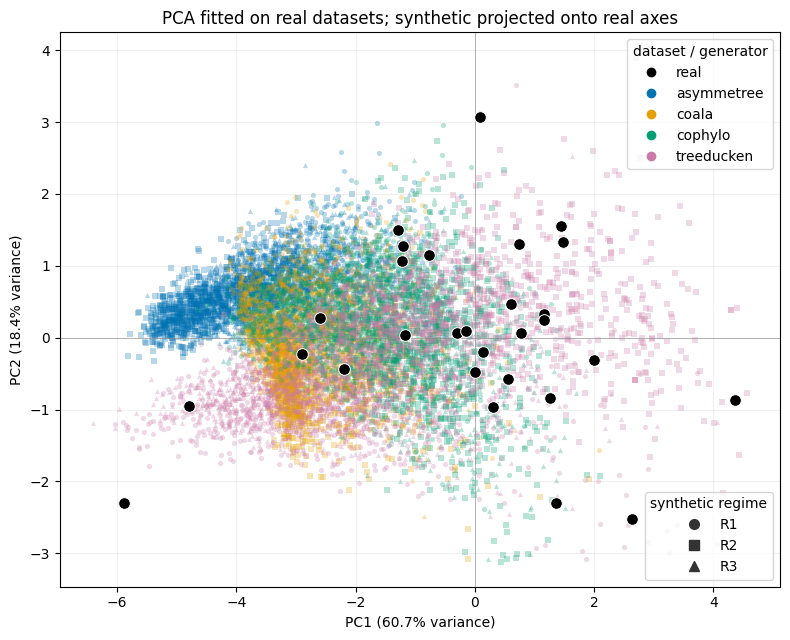

PCA plot saved to: empirical_pca.png


In [7]:
fig, ax = plt.subplots(figsize=(8, 6.5))

for (generator, target_regime), group in standardized_synthetic.groupby(["generator", "target_regime"]):
    ax.scatter(
        group["PC1"],
        group["PC2"],
        s=14,
        alpha=0.28,
        color=GENERATOR_COLORS.get(generator, "#666666"),
        marker=R_MARKERS.get(target_regime, "o"),
        linewidths=0,
    )

ax.scatter(
    standardized_real["PC1"],
    standardized_real["PC2"],
    s=70,
    color="black",
    marker="o",
    edgecolors="white",
    linewidths=0.7,
    zorder=5,
)

ax.axhline(0, color="#888888", linewidth=0.6, alpha=0.7)
ax.axvline(0, color="#888888", linewidth=0.6, alpha=0.7)
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)")
ax.set_title("PCA fitted on real datasets; synthetic projected onto real axes")
ax.grid(alpha=0.18)

generator_handles = [
    Line2D([0], [0], marker="o", color="none", markerfacecolor=color, markeredgecolor="none", markersize=7, label=generator)
    for generator, color in GENERATOR_COLORS.items()
]
regime_handles = [
    Line2D([0], [0], marker=marker, color="#333333", linestyle="none", markersize=7, label=target_regime)
    for target_regime, marker in R_MARKERS.items()
]
real_handle = Line2D([0], [0], marker="o", color="none", markerfacecolor="black", markeredgecolor="white", markersize=8, label="real")
legend1 = ax.legend(handles=[real_handle] + generator_handles, title="dataset / generator", loc="upper right", frameon=True)
ax.add_artist(legend1)
ax.legend(handles=regime_handles, title="synthetic regime", loc="lower right", frameon=True)

fig.tight_layout()
fig.savefig(OUTPUT_FILES["pca"], dpi=220)
plt.show()
print(f"PCA plot saved to: {OUTPUT_FILES['pca']}")

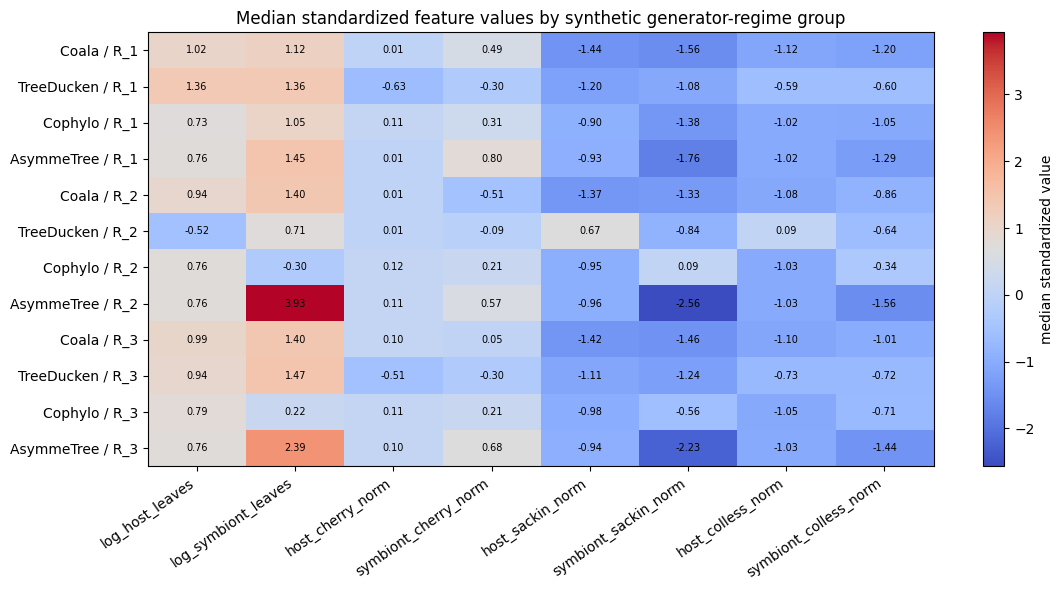

Feature heatmap saved to: feature_heatmap.png


In [8]:
HEATMAP_GENERATOR_ORDER = ["coala", "treeducken", "cophylo", "asymmetree"]
HEATMAP_REGION_ORDER = ["R1", "R2", "R3"]
HEATMAP_GENERATOR_LABELS = {
    "coala": "Coala",
    "treeducken": "TreeDucken",
    "cophylo": "Cophylo",
    "asymmetree": "AsymmeTree",
}

heatmap_data = (
    standardized_synthetic.groupby(["generator", "regime", "target_regime"], as_index=False)[FEATURE_COLUMNS]
    .median()
)
heatmap_data["generator"] = pd.Categorical(
    heatmap_data["generator"], categories=HEATMAP_GENERATOR_ORDER, ordered=True
)
heatmap_data["target_regime"] = pd.Categorical(
    heatmap_data["target_regime"], categories=HEATMAP_REGION_ORDER, ordered=True
)
heatmap_data = heatmap_data.sort_values(["target_regime", "generator"]).reset_index(drop=True)
heatmap_labels = [
    f"{HEATMAP_GENERATOR_LABELS[str(generator)]} / {str(target_regime).replace('R', 'R_')}"
    for generator, target_regime in zip(heatmap_data["generator"], heatmap_data["target_regime"])
]

values = heatmap_data[FEATURE_COLUMNS].to_numpy(dtype=float)
fig_height = max(6.0, 0.42 * len(heatmap_labels))
fig, ax = plt.subplots(figsize=(11.5, fig_height))
im = ax.imshow(values, aspect="auto", cmap="vlag" if "vlag" in plt.colormaps() else "coolwarm")

ax.set_xticks(np.arange(len(FEATURE_COLUMNS)))
ax.set_xticklabels(FEATURE_COLUMNS, rotation=35, ha="right")
ax.set_yticks(np.arange(len(heatmap_labels)))
ax.set_yticklabels(heatmap_labels)
ax.set_title("Median standardized feature values by synthetic generator-regime group")

for row_idx in range(values.shape[0]):
    for col_idx in range(values.shape[1]):
        ax.text(col_idx, row_idx, f"{values[row_idx, col_idx]:.2f}", ha="center", va="center", fontsize=7, color="black")

cbar = fig.colorbar(im, ax=ax)
cbar.set_label("median standardized value")
fig.tight_layout()
fig.savefig(OUTPUT_FILES["heatmap"], dpi=220)
plt.show()
print(f"Feature heatmap saved to: {OUTPUT_FILES['heatmap']}")

In [9]:
print("Saved files:")
for label, path in OUTPUT_FILES.items():
    print(f"{label}: {path}")

print("\nSynthetic-to-real summary:")
display(synthetic_to_real_summary)

print("\nReal-to-synthetic summary:")
display(real_to_synthetic_summary)

print("\nFidelity/coverage summary:")
display(fidelity_coverage_summary)

Saved files:
pca: empirical_pca.png
synthetic_to_real: synthetic_to_real_summary.csv
real_to_synthetic: real_to_synthetic_summary.csv
fidelity_coverage: fidelity_coverage_summary.csv
heatmap: feature_heatmap.png
standardized_real: standardized_real_data.csv
standardized_synthetic: standardized_synthetic_data.csv
selected_ids: selected_synthetic_dataset_ids.csv

Synthetic-to-real summary:


,generator,regime,target_regime,n_synthetic,median_synthetic_to_real_distance,iqr_synthetic_to_real_distance
0,asymmetree,high_switch,R2,1000,3.026038,0.648529
1,asymmetree,low_switch,R1,1000,1.388187,0.414559
2,asymmetree,medium,R3,1000,2.005485,0.577327
3,coala,high_cosp,R1,1000,1.128750,0.418321
4,coala,high_switch,R2,1000,0.993777,0.394070
5,coala,medium,R3,1000,0.903868,0.298974
6,cophylo,high_cosp,R1,1000,1.193125,0.504969
7,cophylo,high_switch,R2,1000,1.404812,0.588835
8,cophylo,medium,R3,1000,1.170151,0.554915
9,treeducken,high_cosp,R1,1000,1.256983,0.461489



Real-to-synthetic summary:


,generator,regime,target_regime,n_real,n_synthetic,median_real_to_synthetic_distance,max_real_to_synthetic_distance
0,asymmetree,high_switch,R2,30,1000,2.803726,6.265156
1,asymmetree,low_switch,R1,30,1000,1.748236,5.052549
2,asymmetree,medium,R3,30,1000,2.065225,5.366229
3,coala,high_cosp,R1,30,1000,1.239045,3.548208
4,coala,high_switch,R2,30,1000,1.011498,3.839960
5,coala,medium,R3,30,1000,1.360481,4.429952
6,cophylo,high_cosp,R1,30,1000,0.929626,3.678272
7,cophylo,high_switch,R2,30,1000,0.874312,4.127405
8,cophylo,medium,R3,30,1000,0.805200,3.203161
9,treeducken,high_cosp,R1,30,1000,1.210189,1.999931



Fidelity/coverage summary:


,generator,regime,target_regime,n_real,n_synthetic,tau,fidelity_percentage,coverage_percentage
0,asymmetree,high_switch,R2,30,1000,1.94519,2.7,20.000000
1,asymmetree,low_switch,R1,30,1000,1.94519,95.1,60.000000
2,asymmetree,medium,R3,30,1000,1.94519,43.8,46.666667
3,coala,high_cosp,R1,30,1000,1.94519,99.5,76.666667
4,coala,high_switch,R2,30,1000,1.94519,98.9,76.666667
5,coala,medium,R3,30,1000,1.94519,99.4,66.666667
6,cophylo,high_cosp,R1,30,1000,1.94519,95.9,90.000000
7,cophylo,high_switch,R2,30,1000,1.94519,85.6,83.333333
8,cophylo,medium,R3,30,1000,1.94519,94.1,83.333333
9,treeducken,high_cosp,R1,30,1000,1.94519,96.3,96.666667
